# 🧪 PySpark & SDP Medallion Playground

Este notebook roda nativamente dentro do container Docker do ambiente **Estudos SDP** com acesso completo ao **Apache Spark 4.1.3**, **Spark Connect**, **Apache Iceberg** e **Apache Kafka**.

In [1]:
from pyspark.sql import SparkSession, DataFrame
import pyspark.sql.functions as F
from pyspark.sql.types import (
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)

# Conectando à sessão ativa do Spark Connect no cluster Docker
spark = SparkSession.builder \
    .remote("sc://spark-connect:15002") \
    .getOrCreate()

print("✅ Conectado com sucesso ao Spark Connect!")
spark.sql("SHOW TABLES IN local.dbo").toPandas()

✅ Conectado com sucesso ao Spark Connect!


,namespace,tableName,isTemporary
0,dbo,bronze_vendas_batch,False
1,dbo,gold_resumo_diario_vendas,False
2,dbo,gold_desempenho_canais,False
3,dbo,bronze_vendas_kafka,False
4,dbo,silver_vendas_batch,False
5,dbo,silver_vendas_kafka,False
6,dbo,silver_vendas_unificadas,False


## 🥉 1. Consulta das Tabelas Bronze (Database: `dbo`)
Exibe os dados brutos de vendas provenientes do arquivo CSV e do streaming Kafka.

In [2]:
print("--- 🥉 dbo.bronze_vendas_batch ---")
spark.table("local.dbo.bronze_vendas_batch").show(10, truncate=False)

kafka_venda_payload_schema = StructType(
    [
        StructField("id_venda", StringType(), True),
        StructField("data_venda", StringType(), True),
        StructField("cliente_id", StringType(), True),
        StructField("produto", StringType(), True),
        StructField("categoria", StringType(), True),
        StructField("valor", DoubleType(), True),
        StructField("quantidade", IntegerType(), True),
        StructField("canal_venda", StringType(), True),
    ]
)

if spark.catalog.tableExists("local.dbo.bronze_vendas_kafka"):
    print("--- 🥉 dbo.bronze_vendas_kafka ---")
    (
        spark.table("local.dbo.bronze_vendas_kafka")
         .withColumn(
             "payload",
             F.from_json("raw_payload", kafka_venda_payload_schema)
         )
        .select("payload.*")
        .show(truncate=False)
    )

--- 🥉 dbo.bronze_vendas_batch ---
+--------+-------------------+----------+------------------+-----------+-------+----------+-----------+--------------------------+---------+
|id_venda|data_venda         |cliente_id|produto           |categoria  |valor  |quantidade|canal_venda|_ingestion_time           |_source  |
+--------+-------------------+----------+------------------+-----------+-------+----------+-----------+--------------------------+---------+
|VND-1001|2026-07-20 10:15:00|CLI-001   |Teclado Mecanico  |Perifericos|250.0  |1         |Loja_Fisica|2026-07-24 04:44:17.417487|BATCH_CSV|
|VND-1002|2026-07-20 11:30:00|CLI-002   |Mouse Sem Fio     |Perifericos|85.5   |2         |E-commerce |2026-07-24 04:44:17.417487|BATCH_CSV|
|VND-1003|2026-07-20 14:22:00|CLI-003   |Monitor 4K 27     |Monitores  |1899.99|1         |E-commerce |2026-07-24 04:44:17.417487|BATCH_CSV|
|VND-1004|2026-07-21 09:05:00|CLI-004   |Cadeira Ergonomica|Mobiliario |1250.0 |1         |Loja_Fisica|2026-07-24 04:44:

## 🥈 2. Consulta da Camada Silver Unificada (Database: `dbo`)
Exibe as vendas consolidadas e higienizadas de todas as origens.

In [3]:
df_silver = spark.table("local.dbo.silver_vendas_unificadas")
print(f"📊 Total de vendas unificadas na Silver: {df_silver.count()}")
df_silver.orderBy(F.col("data_venda").desc()).show(10)

📊 Total de vendas unificadas na Silver: 7
+--------+-------------------+----------+------------------+-----------+--------------+----------+----------------+-----------+--------------------+---------------+
|id_venda|         data_venda|cliente_id|           produto|  categoria|valor_unitario|quantidade|valor_total_item|canal_venda|     _ingestion_time|        _source|
+--------+-------------------+----------+------------------+-----------+--------------+----------+----------------+-----------+--------------------+---------------+
|VND-3436|2026-07-24 01:38:20|   CLI-387|Suporte Articulado| ACESSORIOS|         120.0|         1|           120.0| APP_MOBILE|2026-07-24 04:38:...|STREAMING_KAFKA|
|VND-2433|2026-07-24 01:38:13|   CLI-242|  Teclado Mecanico|PERIFERICOS|         280.0|         3|           840.0| APP_MOBILE|2026-07-24 04:38:...|STREAMING_KAFKA|
|VND-3728|2026-07-24 01:38:08|   CLI-955|    Monitor 27 IPS|  MONITORES|        1400.0|         1|          1400.0| E-COMMERCE|2026-0

## 🥇 3. Datamarts Gold & Análise Gráfica com Pandas e Matplotlib

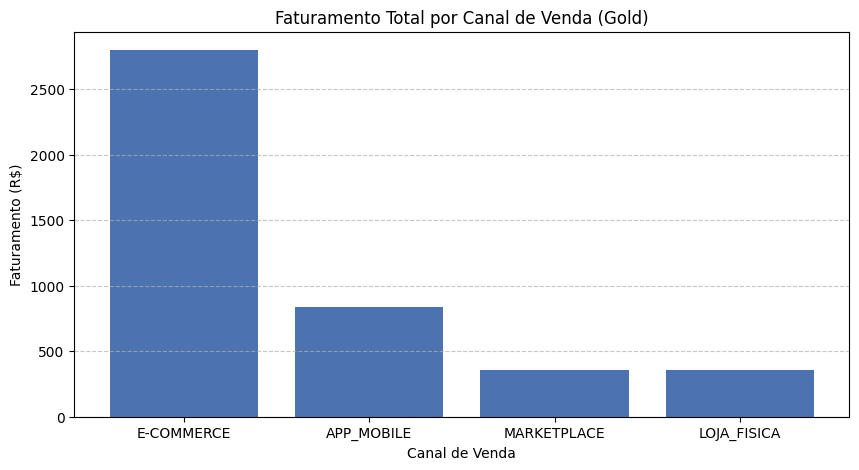

In [4]:
import matplotlib.pyplot as plt

# Convertendo o Datamart Gold para Pandas DataFrame
df_gold_canal = spark.table("local.dbo.gold_desempenho_canais").toPandas()

plt.figure(figsize=(10, 5))
plt.bar(df_gold_canal['canal_venda'], df_gold_canal['faturamento_total'], color='#4C72B0')
plt.title('Faturamento Total por Canal de Venda (Gold)')
plt.xlabel('Canal de Venda')
plt.ylabel('Faturamento (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [5]:
# Verificar as tabela unificada

df_kafka = spark.sql("SELECT * FROM local.dbo.silver_vendas_kafka").toPandas()
df_batch = spark.sql("SELECT * FROM local.dbo.silver_vendas_batch").toPandas()

df_kafka

,id_venda,data_venda,cliente_id,produto,categoria,valor_unitario,quantidade,valor_total_item,canal_venda,_ingestion_time,_source
0,VND-4282,2026-07-24 01:37:46,CLI-658,Monitor 27 IPS,MONITORES,1400.0,1,1400.0,E-COMMERCE,2026-07-24 04:38:27.815,STREAMING_KAFKA
1,VND-2985,2026-07-24 01:37:52,CLI-952,Suporte Articulado,ACESSORIOS,120.0,3,360.0,LOJA_FISICA,2026-07-24 04:38:27.815,STREAMING_KAFKA
2,VND-4404,2026-07-24 01:37:57,CLI-516,Suporte Articulado,ACESSORIOS,120.0,3,360.0,MARKETPLACE,2026-07-24 04:38:27.815,STREAMING_KAFKA
3,VND-3129,2026-07-24 01:38:02,CLI-708,Mouse Sem Fio,PERIFERICOS,150.0,2,300.0,MARKETPLACE,2026-07-24 04:38:27.815,STREAMING_KAFKA
4,VND-3728,2026-07-24 01:38:08,CLI-955,Monitor 27 IPS,MONITORES,1400.0,1,1400.0,E-COMMERCE,2026-07-24 04:38:27.815,STREAMING_KAFKA
5,VND-2433,2026-07-24 01:38:13,CLI-242,Teclado Mecanico,PERIFERICOS,280.0,3,840.0,APP_MOBILE,2026-07-24 04:38:27.815,STREAMING_KAFKA
6,VND-3436,2026-07-24 01:38:20,CLI-387,Suporte Articulado,ACESSORIOS,120.0,1,120.0,APP_MOBILE,2026-07-24 04:38:27.815,STREAMING_KAFKA


In [6]:
spark.sql("REFRESH TABLE local.dbo.silver_vendas_unificadas").show()

spark.sql("""
 select * from local.dbo.silver_vendas_unificadas order by id_venda ASC
""").toPandas()

++
||
++
++



,id_venda,data_venda,cliente_id,produto,categoria,valor_unitario,quantidade,valor_total_item,canal_venda,_ingestion_time,_source
0,VND-2433,2026-07-24 01:38:13,CLI-242,Teclado Mecanico,PERIFERICOS,280.0,3,840.0,APP_MOBILE,2026-07-24 04:38:27.815,STREAMING_KAFKA
1,VND-2985,2026-07-24 01:37:52,CLI-952,Suporte Articulado,ACESSORIOS,120.0,3,360.0,LOJA_FISICA,2026-07-24 04:38:27.815,STREAMING_KAFKA
2,VND-3129,2026-07-24 01:38:02,CLI-708,Mouse Sem Fio,PERIFERICOS,150.0,2,300.0,MARKETPLACE,2026-07-24 04:38:27.815,STREAMING_KAFKA
3,VND-3436,2026-07-24 01:38:20,CLI-387,Suporte Articulado,ACESSORIOS,120.0,1,120.0,APP_MOBILE,2026-07-24 04:38:27.815,STREAMING_KAFKA
4,VND-3728,2026-07-24 01:38:08,CLI-955,Monitor 27 IPS,MONITORES,1400.0,1,1400.0,E-COMMERCE,2026-07-24 04:38:27.815,STREAMING_KAFKA
5,VND-4282,2026-07-24 01:37:46,CLI-658,Monitor 27 IPS,MONITORES,1400.0,1,1400.0,E-COMMERCE,2026-07-24 04:38:27.815,STREAMING_KAFKA
6,VND-4404,2026-07-24 01:37:57,CLI-516,Suporte Articulado,ACESSORIOS,120.0,3,360.0,MARKETPLACE,2026-07-24 04:38:27.815,STREAMING_KAFKA


In [30]:
# gold_resumo_diario_vendas
# gold_desempenho_canais
"""
189692593685145229
4530796637589068328
"""

table_name = "silver_vendas_kafka"
versions = spark.sql(f"select snapshot_id from dbo.{table_name}.snapshots order by committed_at asc").collect()
for pv, ver in enumerate(versions):
    [linhas] = spark.sql(f"select count(*) from dbo.{table_name} FOR VERSION AS OF {ver.snapshot_id}").collect()[0]
    print(f"Version: {pv}, registros: {linhas}")

Version: 0, registros: 7
Version: 1, registros: 0
Version: 2, registros: 7
Version: 3, registros: 0
Version: 4, registros: 33


In [ ]:
spark.sql("select * from dbo.